# CaCO3 precipitation with CO2(g)
- solves saturated concentration of Ca2+ under fixed pCO2
- considers activity coefficients (Davies model)

In [1]:
import sys
sys.path.append('../')

In [2]:
from pprint import pprint
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Load data

In [3]:
import eq_solver

In [4]:
# read equilibrium system definition
path = '040.yaml'
s = eq_solver.System.from_yaml(path)

# Note that for 'carbonate' component, constraint is DIRECT and base_species is CO2(g).
s.components

(Component(name='proton', constraint=<Constraint.CHARGE: 1>, base_species=Species(name='H+'), base_charge=1),
 Component(name='carbonate', constraint=<Constraint.DIRECT: 2>, base_species=Species(name='CO2(g)'), base_charge=0),
 Component(name='calcium', constraint=<Constraint.TOTAL: 0>, base_species=Species(name='Ca2+'), base_charge=2))

# Problem 1: saturated concentration of Ca(OH)2

In [5]:
# no CO2, Ca2+ > sat. concentration
cond = eq_solver.Conditions.from_dict(
    system=s,
    conditions={'carbonate': 0.0, 'calcium': 0.1}
)
f = eq_solver.FitFunc(system=s, cond=cond)
r = f.solve()
print(f'- total Ca2+ = {r.total_conc_in_liquid("calcium"):.3f} mol/L')
print(f'-         pH = {r.pH():.2f}')

- total Ca2+ = 0.021 mol/L
-         pH = 12.48


In [6]:
# Details
print('- concentration of each species: ')
display(pd.Series(r.spc_c, index=s.species))
print('- solver results: ')
pprint(r)

- concentration of each species: 


Species(name='H+')            4.050646e-13
Species(name='OH-')           3.680742e-02
Species(name='CO2(g)')        0.000000e+00
Species(name='CO2aq')         0.000000e+00
Species(name='HCO3-')         0.000000e+00
Species(name='CO3^2-')        0.000000e+00
Species(name='Ca2+')          1.579459e-02
Species(name='[CaCO3]aq')     0.000000e+00
Species(name='[CaHCO3]aq')    0.000000e+00
Species(name='CaCO3(s)')      6.783818e-08
Species(name='[CaOH]+aq')     5.218243e-03
Species(name='Ca(OH)2(s)')    7.898710e-02
dtype: float64

- solver results: 
SolverResults(spc_c=array([4.05064619e-13, 3.68074184e-02, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 1.57945876e-02, 0.00000000e+00,
       0.00000000e+00, 6.78381778e-08, 5.21824314e-03, 7.89871014e-02]),
              spc_a=array([3.31737431e-13, 3.01443222e-02, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 7.10540691e-03, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 4.27360597e-03, 1.00000000e+00]),
              retries=0,
              ionic_strength=np.float64(0.05260200596073932),
              rmse=np.float64(3.03381288468038e-07))


# Problem 2: Ca2+ solution, under given pCO2

In [7]:
pco2 = np.logspace(-6, 1, 100)
ca = 0.02  # total mole of Ca2+
cond_list = [eq_solver.Conditions.from_dict(s, {'carbonate': p, 'calcium': ca}) for p in pco2]

In [8]:
l = eq_solver.solve_for_conditions(s, cond_list)
df = eq_solver.get_total_aq(l)
df  # negative total proton(aq) means H+ consumption through reactions.

,cond.direct.carbonate,cond.total.calcium,sol.rmse,sol.retries,sol.nfev,pH,proton,carbonate,calcium
0,0.000001,0.02,3.350926e-07,0,24,9.792259,-0.000249,0.000147,0.000124
1,0.000001,0.02,5.539354e-08,0,5,9.754630,-0.000251,0.000155,0.000126
2,0.000001,0.02,1.200842e-08,0,5,9.716416,-0.000255,0.000163,0.000127
3,0.000002,0.02,2.858081e-09,0,5,9.677630,-0.000259,0.000173,0.000129
4,0.000002,0.02,7.604062e-10,0,5,9.638289,-0.000263,0.000182,0.000132
...,...,...,...,...,...,...,...,...,...
95,5.214008,0.02,1.304355e-07,0,16,5.515994,-0.040000,0.216671,0.020000
96,6.135907,0.02,1.356765e-07,0,16,5.445312,-0.040000,0.247911,0.020000
97,7.220809,0.02,4.351307e-08,0,5,5.374628,-0.040000,0.284674,0.020000
98,8.497534,0.02,1.690928e-08,0,5,5.303943,-0.040000,0.327936,0.020000


In [9]:
# save data as csv
df_summary = eq_solver.get_summary(l)
display(df_summary.head())
df_summary.to_csv('CaCO3-under-pCO2.csv', encoding='utf-8')

,cond.direct.carbonate,cond.total.calcium,sol.rmse,sol.retries,sol.nfev,pH,ionic strength,c_total.proton,c_total.carbonate,c_total.calcium,...,a.CO2(g),a.CO2aq,a.HCO3-,a.CO3^2-,a.Ca2+,a.[CaCO3]aq,a.[CaHCO3]aq,a.CaCO3(s),a.[CaOH]+aq,a.Ca(OH)2(s)
0,0.000001,0.02,3.350926e-07,0,24,9.792259,0.000390,-0.000249,0.000147,0.000124,...,0.000001,3.388442e-08,0.000105,0.000031,0.000109,0.000005,2.126872e-07,1.0,1.341966e-07,6.456542e-08
1,0.000001,0.02,5.539354e-08,0,5,9.754630,0.000394,-0.000251,0.000155,0.000126,...,0.000001,3.987559e-08,0.000114,0.000030,0.000110,0.000005,2.319369e-07,1.0,1.243549e-07,5.486469e-08
2,0.000001,0.02,1.200842e-08,0,5,9.716416,0.000398,-0.000255,0.000163,0.000127,...,0.000001,4.692607e-08,0.000122,0.000030,0.000111,0.000005,2.532702e-07,1.0,1.153904e-07,4.662146e-08
3,0.000002,0.02,2.858081e-09,0,5,9.677630,0.000404,-0.000259,0.000173,0.000129,...,0.000002,5.522315e-08,0.000132,0.000029,0.000113,0.000005,2.769300e-07,1.0,1.072133e-07,3.961674e-08
4,0.000002,0.02,7.604062e-10,0,5,9.638289,0.000410,-0.000263,0.000182,0.000132,...,0.000002,6.498727e-08,0.000142,0.000029,0.000115,0.000005,3.031875e-07,1.0,9.974315e-08,3.366447e-08


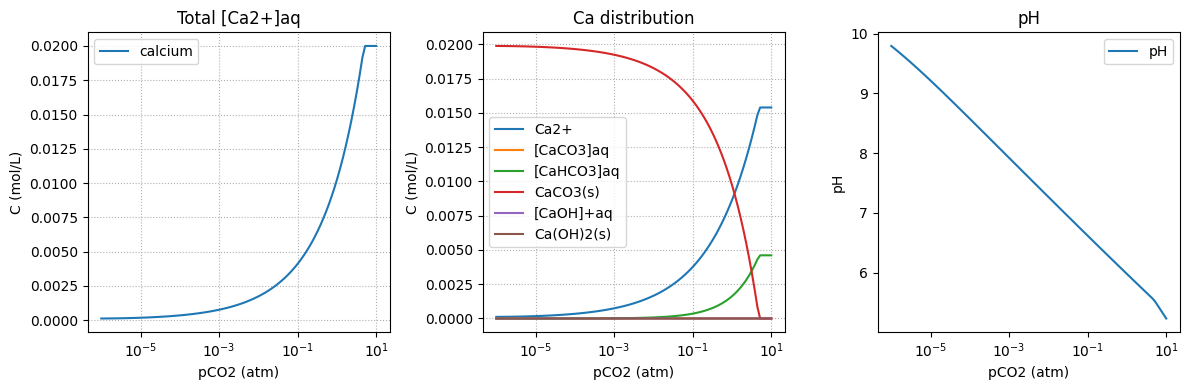

In [10]:
# Total solubility of Ca2+, Ca2+ distribution, pH
fig, axes = plt.subplots(ncols=3)
fig.set_size_inches(12, 4)
plt.sca(axes[0])
df.plot(x='cond.direct.carbonate', y='calcium', title='Total [Ca2+]aq', ax=axes[0])
plt.xscale('log')
plt.ylabel('C (mol/L)')
plt.xlabel('pCO2 (atm)')
plt.grid(True, ls=':')

plt.sca(axes[1])
df_Ca = eq_solver.get_distribution(l, 'calcium')
df_Ca.plot(x='cond.direct.carbonate', title='Ca distribution',
           y=[c for c in df_Ca.columns if 'Ca' in c], 
           ax=axes[1])
plt.xscale('log')
plt.ylabel('C (mol/L)')
plt.xlabel('pCO2 (atm)')
plt.grid(True, ls=':')

plt.sca(axes[2])
df.plot(x='cond.direct.carbonate', y='pH', title='pH', ax=axes[2])
plt.xscale('log')
plt.ylabel('pH')
plt.xlabel('pCO2 (atm)')
fig.set_tight_layout(True)